# Why Long and Short Returns Aren’t Symmetric with Simple Returns (FX Example)

This notebook answers one specific question:

**If EUR/USD goes up, is the short-side return always just the negative of the long-side return?**

In FX, a quote like **EUR/USD = 1.10** means:
- 1 EUR costs 1.10 USD
- EUR is the base currency
- USD is the quote currency

We will use this same move everywhere:
- At $t_0$: EUR/USD = 1.10
- At $t_1$: EUR/USD = 1.25

So the euro appreciated versus the dollar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.8f}'.format

## 2) Setup

We define the starting and ending exchange rates once, then reuse them in each calculation.

In [2]:
eurusd_t0 = 1.10
eurusd_t1 = 1.25

## 3) Long EUR Position with Simple Return

Think of a long EUR position in three simple steps:
1. Buy EUR at the initial rate
2. Hold EUR while the rate changes
3. Value/sell EUR at the new rate

Using 1 EUR:
- Start value = $1.10
- End value = $1.25

Simple-return formula:

$r_{\text{long,simple}} = \frac{S_{t_1}}{S_{t_0}} - 1$

where $S$ is EUR/USD.

Interpretation: if this return is positive, the long EUR trade made money in USD terms.

In [3]:
r_long_simple = eurusd_t1 / eurusd_t0 - 1
print(f'Long EUR simple return: {r_long_simple:.2%}')

Long EUR simple return: 13.64%


## 4) Intuitive but Wrong Expectation

A lot of people expect this:

$r_{\text{short,simple}} = -r_{\text{long,simple}}$

That would mean long and short are perfectly symmetric.

In FX with **simple returns**, that usually fails because short EUR is naturally expressed through the inverted quote (USD/EUR), which changes the percentage base.

## 5) Short EUR (Long USD) via Inverted Rate

To represent short EUR clearly, invert the quote:
- EUR/USD = dollars per euro
- USD/EUR = euros per dollar

If EUR/USD is $S$, then USD/EUR is $1/S$.

So we compute the short-side simple return from USD/EUR:

$r_{\text{short,simple}} = \frac{(1/S)_{t_1}}{(1/S)_{t_0}} - 1$

Then we compare:
- long simple return
- naive negative of long return
- actual short simple return

In [4]:
usdeur_t0 = 1 / eurusd_t0
usdeur_t1 = 1 / eurusd_t1

r_short_simple = usdeur_t1 / usdeur_t0 - 1

print(f'EUR/USD t0: {eurusd_t0:.6f}')
print(f'EUR/USD t1: {eurusd_t1:.6f}')
print(f'USD/EUR t0: {usdeur_t0:.6f}')
print(f'USD/EUR t1: {usdeur_t1:.6f}')
print()
print(f'r_long_simple:                    {r_long_simple:.6%}')
print(f'-r_long_simple (naive expected): {-r_long_simple:.6%}')
print(f'r_short_simple (actual):         {r_short_simple:.6%}')

EUR/USD t0: 1.100000
EUR/USD t1: 1.250000
USD/EUR t0: 0.909091
USD/EUR t1: 0.800000

r_long_simple:                    13.636364%
-r_long_simple (naive expected): -13.636364%
r_short_simple (actual):         -12.000000%


### Quick takeaway from the numbers

The actual short simple return is not exactly the negative of the long simple return.

So the asymmetry is real and measurable, not just a theory point.

## 6) Transaction Intuition (1-unit examples)

Now we show the same idea using cashflows (very concrete).

Long EUR, measured in USD:
- Pay USD now to buy EUR
- Receive USD later when EUR is revalued/sold
- P&L is in USD

Long USD / short EUR, measured in EUR:
- Pay EUR now to buy USD
- Receive EUR later from the USD position
- P&L is in EUR

Important idea: these are different numeraires (measurement currencies).
Different numeraires can produce non-mirrored simple returns.

In [5]:
# Long EUR (USD numeraire)
usd_outflow_long_eur = eurusd_t0
usd_inflow_long_eur = eurusd_t1
usd_pnl_long_eur = usd_inflow_long_eur - usd_outflow_long_eur

# Long USD / short EUR (EUR numeraire)
eur_outflow_long_usd = usdeur_t0
eur_inflow_long_usd = usdeur_t1
eur_pnl_long_usd = eur_inflow_long_usd - eur_outflow_long_usd

print('Long EUR (USD numeraire):')
print(f'  Pay at t0: ${usd_outflow_long_eur:.6f}')
print(f'  Receive at t1: ${usd_inflow_long_eur:.6f}')
print(f'  P&L: ${usd_pnl_long_eur:.6f}')
print()
print('Long USD / Short EUR (EUR numeraire):')
print(f'  Pay at t0: €{eur_outflow_long_usd:.6f}')
print(f'  Receive at t1: €{eur_inflow_long_usd:.6f}')
print(f'  P&L: €{eur_pnl_long_usd:.6f}')

Long EUR (USD numeraire):
  Pay at t0: $1.100000
  Receive at t1: $1.250000
  P&L: $0.150000

Long USD / Short EUR (EUR numeraire):
  Pay at t0: €0.909091
  Receive at t1: €0.800000
  P&L: €-0.109091


## 7) Log Returns Restore Symmetry

Log returns fix the inversion issue neatly.

Definitions:
- $r_{\text{long,log}} = \ln(S_{t_1}/S_{t_0})$
- $r_{\text{short,log}} = \ln((1/S)_{t_1}/(1/S)_{t_0})$

Algebra gives:

$r_{\text{short,log}} = -r_{\text{long,log}}$

So when we add them, the result should be approximately zero (up to floating-point rounding).

In [6]:
r_long_log = np.log(eurusd_t1 / eurusd_t0)
r_short_log = np.log(usdeur_t1 / usdeur_t0)

print(f'r_long_log:  {r_long_log:.8f}')
print(f'r_short_log: {r_short_log:.8f}')
print(f'r_long_log + r_short_log (should be ~0): {r_long_log + r_short_log:.12f}')

r_long_log:  0.12783337
r_short_log: -0.12783337
r_long_log + r_short_log (should be ~0): 0.000000000000


### Why this matters in practice

Quants often prefer log returns because:
- long/short FX inversion stays symmetric
- multi-period aggregation is easier (log returns add)
- portfolio/risk calculations are cleaner

## 8) Extend to 20 Random Scenarios

To make sure this is not a one-case artifact, we run 20 random EUR/USD moves.

For each scenario, we compute:
- long and short simple returns
- long and short log returns
- symmetry error for both methods

Symmetry error is defined as long + short:
- if perfectly symmetric, error is 0

In [7]:
rng = np.random.default_rng(42)
n_scenarios = 20

scenario_df = pd.DataFrame({
    'eurusd_t0': rng.uniform(1.0, 1.5, n_scenarios),
    'random_move': rng.uniform(-0.2, 0.2, n_scenarios)
})
scenario_df['eurusd_t1'] = scenario_df['eurusd_t0'] * (1 + scenario_df['random_move'])

scenario_df['usdeur_t0'] = 1 / scenario_df['eurusd_t0']
scenario_df['usdeur_t1'] = 1 / scenario_df['eurusd_t1']

scenario_df['long_simple'] = scenario_df['eurusd_t1'] / scenario_df['eurusd_t0'] - 1
scenario_df['short_simple'] = scenario_df['usdeur_t1'] / scenario_df['usdeur_t0'] - 1

scenario_df['long_log'] = np.log(scenario_df['eurusd_t1'] / scenario_df['eurusd_t0'])
scenario_df['short_log'] = np.log(scenario_df['usdeur_t1'] / scenario_df['usdeur_t0'])

scenario_df['simple_symmetry_error'] = scenario_df['long_simple'] + scenario_df['short_simple']
scenario_df['log_symmetry_error'] = scenario_df['long_log'] + scenario_df['short_log']

summary = scenario_df[['simple_symmetry_error', 'log_symmetry_error']].agg(['mean', 'std', 'min', 'max'])
print('Symmetry error summary stats:')
print(summary)

scenario_df.head()

Symmetry error summary stats:
      simple_symmetry_error  log_symmetry_error
mean             0.01341221          0.00000000
std              0.01168501          0.00000000
min              0.00009537         -0.00000000
max              0.04073092          0.00000000


,eurusd_t0,random_move,eurusd_t1,usdeur_t0,usdeur_t1,long_simple,short_simple,long_log,short_log,simple_symmetry_error,log_symmetry_error
0,1.38697802,0.10323510,1.53016283,0.72099196,0.65352522,0.10323510,-0.09357488,0.09824686,-0.09824686,0.00966021,-0.00000000
1,1.21943922,-0.05818961,1.14848052,0.82004907,0.87071568,-0.05818961,0.06178485,-0.05995131,0.05995131,0.00359524,0.00000000
2,1.42929896,0.18827921,1.69840624,0.69964369,0.58878729,0.18827921,-0.15844694,0.17250622,-0.17250622,0.02983227,-0.00000000
3,1.34868401,0.15724845,1.56076248,0.74146352,0.64071248,0.15724845,-0.13588132,0.14604516,-0.14604516,0.02136713,-0.00000000
4,1.04708867,0.11135340,1.16368556,0.95502895,0.85933867,0.11135340,-0.10019621,0.10557855,-0.10557855,0.01115719,0.00000000


## 9) Plot Symmetry Error Across Scenarios

How to read the chart:
- `simple_symmetry_error` line away from 0 means simple returns are not symmetric
- `log_symmetry_error` line near 0 means log returns preserve symmetry

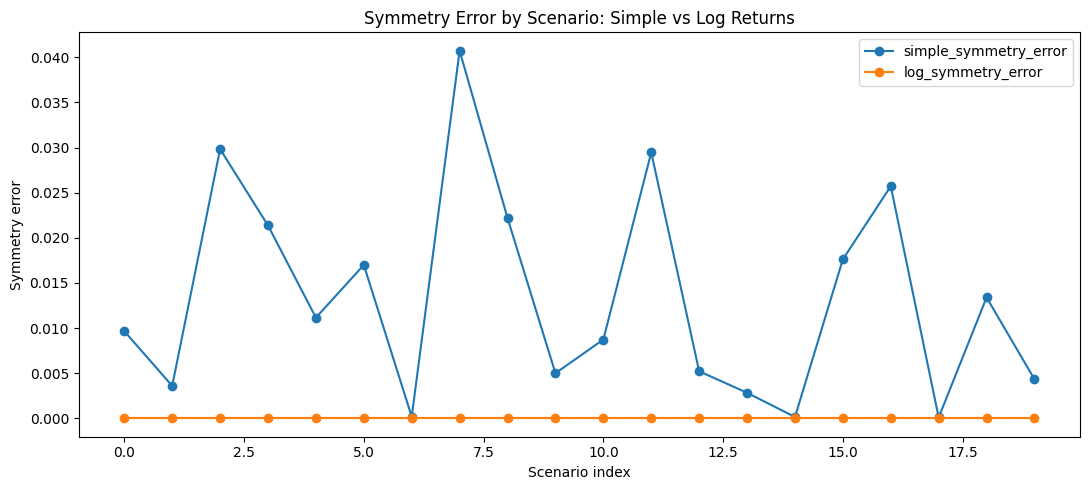

In [8]:
plt.figure(figsize=(11, 5))
plt.plot(scenario_df.index, scenario_df['simple_symmetry_error'], marker='o', label='simple_symmetry_error')
plt.plot(scenario_df.index, scenario_df['log_symmetry_error'], marker='o', label='log_symmetry_error')
plt.title('Symmetry Error by Scenario: Simple vs Log Returns')
plt.xlabel('Scenario index')
plt.ylabel('Symmetry error')
plt.legend()
plt.tight_layout()
plt.show()

## 10) Wrap-up

- Long EUR and short EUR are conceptual opposites, but simple-return percentages are not exact negatives after quote inversion.
- The mismatch comes from using different bases/measurement currencies (numeraire effect).
- Log returns remove this inversion asymmetry: long log return + short log return ≈ 0.
- In FX analysis, always state both quote direction and numeraire before interpreting returns.